In [24]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import scipy.constants as const
import csv

Definisco la mia condizione iniziale e al contorno del sistema

In [25]:
def init_CC(n, rho, R):
    i = 0
    a = 1./(rho)**(1/3)
    for k in range(n):
        for l in range(n):
            for m in range(n):
                R[i][0] = k*a
                R[i][1] = l*a
                R[i][2] = m*a
                i+=1

In [26]:
def init_BCC(n, rho, R):
    i = 0
    a = 2./(rho)**(1/3)
    for k in range(n):
        for l in range(n):
            for m in range(n):
                R[i][0] = k*a
                R[i][1] = l*a
                R[i][2] = m*a
                i+=1
                R[i][0] = k*a + 1./2
                R[i][1] = l*a + 1./2
                R[i][2] = m*a + 1./2
                i+=1

Definisco le funzioni per calcolare le distanze

In [27]:
def dist(R, p, q, L):
    return np.sqrt((R[p][0]-R[q][0]-L*np.rint((R[p][0] - R[q][0])/L))*(R[p][0]-R[q][0]-L*np.rint((R[p][0] - R[q][0])/L))+(R[p][1]-R[q][1]-L*np.rint((R[p][1] - R[q][1])/L))*(R[p][1]-R[q][1]-L*np.rint((R[p][1] - R[q][1])/L))+(R[p][2]-R[q][2]-L*np.rint((R[p][2] - R[q][2])/L))*(R[p][2]-R[q][2]-L*np.rint((R[p][2] - R[q][2])/L)))

In [28]:
def dist2(R, Rpq, p, q, L):
    Rpq[0] = R[p][0] - R[q][0]-L*np.rint((R[p][0] - R[q][0])/L)
    Rpq[1] = R[p][1] - R[q][1]-L*np.rint((R[p][1] - R[q][1])/L)
    Rpq[2] = R[p][2] - R[q][2]-L*np.rint((R[p][2] - R[q][2])/L)

Definisco il potenziale di Lennard-Jones

In [29]:
def V(r, L, sigma, epsilon):
    r6 = (sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)
    L6 = (2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)
    if r<=L/2:
        return 4*epsilon*r6*(r6 - 1) - 4*epsilon*L6*(L6 - 1)
    else:
        return 0

Definisco le funzioni u facenti parte della funzione d'onda

In [30]:
def u(r, a1):
    return (a1/r)*(a1/r)*(a1/r)*(a1/r)*(a1/r)

In [31]:
def u2(r, a1, L):
    if r<=L/2:
        return u(r, a1) + u(L-r, a1) - 2*u(L/2, a1)
    else:
        return 0

In [32]:
def u_prime(r, a1, L):
    return -5*(a1**5)*(r**(-6))

In [33]:
def u_second(r, a1, L):
    return 30*(a1*5)*(r**(-7))

In [34]:
def u2_prime(r, a1, L):
    if r<=L/2:
        return u_prime(r, a1, L) - u_prime(L-r, a1, L)
    else:
        return 0

In [41]:
def u2_second(r, a1, L):
    if r<=L/2:
        return u_second(r, a1, L) + u_second(L-r, a1, L)
    else:
        return 0

Definisco la funzione d'onda e il suo modulo quadro

In [36]:
def logpsi(R, a1, L, N):
    u_f = 0
    for i in range(N-1):
        for j in range(i+1, N):
            r_ij = dist(R, i, j, L)
            u_f += u2(r_ij, a1, L)
    
    return -0.5*u_f

Definisco la funzione che attua il metodo di Montecarlo

In [45]:
def montecarlo(N, R, D, L, alpha, sigma, epsilon, step_number):
    rng = np.random.default_rng(123)
    h = 6.0596
    accept = 0
    reject = 0
    E = 0
    wf_old = logpsi(R, alpha, L, N)
    with open("vmc.csv", "w") as f:
        ff = csv.writer(f)
        ff.writerow(["Tempo", "Energia", "Accettazioni/step"])
    
    #Calcolo l'energia iniziale
    for i in range(N):
        for j in range(i+1, N):
            r = dist(R, i, j, L)
            E += V(r, L, sigma, epsilon)
    
    for i in range(N):
        K_i = 0
        for j in range(N):
            r_ij = dist(R, i, j, L)
            if j!=i:
                K_i -= u2_prime(r_ij, alpha, L) + u2_second(r_ij, alpha, L)/2
                for l in range(N):
                    R_ij = np.zeros(3)
                    R_il = np.zeros(3)
                    dist2(R, R_ij, i, j, L)
                    dist2(R, R_il, i, l, L)
                    r_il = dist(R, i, l, L)
                    if l!=i:
                        K_i += (R_ij[0]*R_il[0]+R_ij[1]*R_il[1]+R_ij[2]*R_il[2])*u2_prime(r_ij, alpha, L)*u2_prime(r_il, alpha, L)/4
        E -= h*K_i
    #salvo i dati iniziali su file    
    with open("vmc.csv", "a") as f:
        ff = csv.writer(f)
        ff.writerow([0, E, 0.0])
    
    #Comincio a ciclare gli step per l'algoritmo di Metropolis
    for i in range(1, step_number+1):
        E_new = 0
        R_new = np.zeros((N,3))
        #while(True):
        for j in range(N):
            for k in range(3):
                R_new[j][k] = R[j][k]+D*(rng.random()+0.5)
            # test = np.unique(R_new, axis=0)
            # if R_new.size == test.size:
            #     break
        wf_new = logpsi(R_new, alpha, L, N)
        print(wf_old, "   ", wf_new)
        #Calcolo l'energia per l'evoluzione proposta
        for j in range(N):
            for k in range(j+1, N):
                r = dist(R_new, j, k, L)
                E_new += V(r, L, sigma, epsilon)
        for j in range(N):
            K_j = 0
            for k in range(N):
                r_jk = dist(R_new, j, k, L)
                if k!=j:
                    K_j -= u2_prime(r_jk, alpha, L) + u2_second(r_jk, alpha, L)/2
                    for l in range(N):
                        R_jk = np.zeros(3)
                        R_jl = np.zeros(3)
                        dist2(R_new, R_jk, j, k, L)
                        dist2(R_new, R_jl, j, l, L)
                        r_jl = dist(R, j, l, L)
                        if l!=j:
                            K_j += (R_jk[0]*R_jl[0]+R_jk[1]*R_jl[1]+R_jk[2]*R_jl[2])*u2_prime(r_jk, alpha, L)*u2_prime(r_jl, alpha, L)/4
            E_new -= h*K_j
        
        #Controllo se accettare o meno l'evoluzione proposta
        if 2.0*(wf_new-wf_old) > np.log(rng.random()):
            for j in range(N):
                for k in range(3):
                    R[j][k] = R_new[j][k]
            E = E_new
            wf_old = wf_new
            accept+=1
        else:
            reject+=1
        
        #Salvo l'energia nel file
        with open("vmc.csv", "a") as f:
            ff = csv.writer(f)
            ff.writerow([i, E, float(accept)/float(i)])
        
    return float(accept)/float(reject)

Dichiaro e inizializzo le variabili del problema

In [38]:
N = 64
n = 4
rho = 0.0218
L = (N/rho)**(1/3)
D = 0.27
eps = 10.22
sigma = 2.556
alpha = 2.5
R = np.zeros((N,3))
step_number = 5000

Creo il mio sistema iniziale e faccio un plot delle particelle in questa configurazione

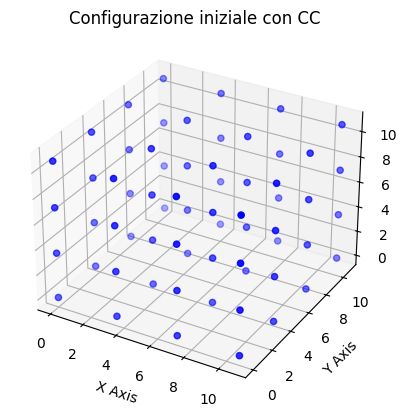

In [39]:
init_CC(n, rho, R)

x = R[:, 0]
y = R[:, 1]
z = R[:, 2]

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.scatter(x, y, z, c='blue', s=20)
plt.title("Configurazione iniziale con CC")
plt.show()

In [46]:
rate = montecarlo(N, R, D, L, alpha, sigma, eps, step_number)

-19.32838772206712     -19.50299133677535
-19.32838772206712     -19.504861763397514
-19.504861763397514     -19.718301416476642
-19.718301416476642     -19.883048040313902
-19.883048040313902     -19.998800035326905
-19.998800035326905     -20.334989971074904
-20.334989971074904     -20.506716764401627
-20.506716764401627     -20.72980631995177
-20.72980631995177     -21.001823888087767
-20.72980631995177     -20.80270010247275
-20.80270010247275     -20.93529859374872
-20.93529859374872     -21.254170880887468
-20.93529859374872     -20.934367450632692
-20.934367450632692     -21.132725613048652
-20.934367450632692     -21.13719938219038
-21.13719938219038     -21.043979750292305
-21.043979750292305     -21.4208537594891
-21.4208537594891     -21.413507394359346
-21.413507394359346     -21.658815906930368
-21.413507394359346     -21.614280661577816
-21.413507394359346     -21.699582794746433
-21.699582794746433     -22.05109169698308
-22.05109169698308     -22.14929480807963
-22.1492